<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


## 1. Corpus

In [1]:
import re
import json
import urllib.request
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

Se utiliza **Don Quijote de la Mancha** (Cervantes, dominio público) desde Project Gutenberg. El texto se descarga una sola vez y se guarda en local, así el notebook no depende de la red en las siguientes ejecuciones.

Se elige un libro extenso porque un modelo por caracteres necesita muchos datos: cada carácter es una muestra, y el vocabulario es muy chico (decenas de símbolos) comparado con el de un modelo por palabras.

In [2]:
CORPUS_URL = "https://www.gutenberg.org/cache/epub/2000/pg2000.txt"
CORPUS_PATH = Path("quijote.txt")

if not CORPUS_PATH.exists():
    with urllib.request.urlopen(CORPUS_URL) as r:
        CORPUS_PATH.write_bytes(r.read())

raw_text = CORPUS_PATH.read_text(encoding="utf-8-sig")
print(f"Caracteres totales (crudo): {len(raw_text):,}")

Caracteres totales (crudo): 2,130,057


Project Gutenberg agrega una licencia al inicio y al final del archivo que no es parte de la obra; se recorta usando sus marcadores.

In [3]:
start = raw_text.index("*** START OF")
start = raw_text.index("\n", start) + 1
end = raw_text.index("*** END OF")
book = raw_text[start:end]

print(f"Caracteres del libro: {len(book):,}")
print(book[:600])

Caracteres del libro: 2,110,737




El ingenioso hidalgo don Quijote de la Mancha



por Miguel de Cervantes Saavedra





El ingenioso hidalgo don Quijote de la Mancha


  
Tasa

  
Testimonio de las erratas

  
El Rey

  
Al Duque de Béjar

  
Prólogo

  
Al libro de don Quijote de la Mancha



Que trata de la condición y ejercicio del famoso
hidalgo don Quijote de la Mancha

Que trata de la primera salida que de su tierra hizo
el ingenioso don Quijote

Donde se cuenta la graciosa manera que tuvo don
Quijote en armarse caballero

De lo que le sucedió a nuestro caballero cuando salió
de la venta

Donde se prosigue la narrac


## 2. Pre-procesamiento, tokenización y dataset

### Limpieza

- Pasar a minúsculas: reduce el vocabulario sin perder mucha información para este objetivo.
- Normalizar espacios y saltos de línea: el archivo tiene cortes de línea fijos a mitad de oración que no son parte del texto; se reemplazan por un espacio.
- Eliminar caracteres muy poco frecuentes (símbolos raros, artefactos de edición): agrandan la capa de salida y casi nunca se predicen bien.

In [4]:
text = book.lower()
text = re.sub(r"\s+", " ", text).strip()

freq = Counter(text)
print(f"Caracteres distintos antes de filtrar: {len(freq)}")

# distribución de frecuencias: los raros están al final
for ch, n in sorted(freq.items(), key=lambda kv: kv[1])[:25]:
    print(repr(ch), n)

Caracteres distintos antes de filtrar: 61
'à' 1
'7' 1
'5' 1
'2' 1
'3' 1
']' 2
'0' 2
'4' 2
'w' 2
'ù' 2
'6' 4
'ï' 4
'1' 8
'«' 57
'(' 62
')' 62
'ü' 89
'-' 109
'"' 166
'»' 290
'x' 380
'¡' 685
'!' 693
"'" 704
'¿' 959


In [5]:
MIN_FREQ = 70  # caracteres con menos apariciones se eliminan

rare = {ch for ch, n in freq.items() if n < MIN_FREQ}
text = "".join(ch for ch in text if ch not in rare)

print(f"Eliminados: {sorted(rare)}")
print(f"Caracteres del corpus limpio: {len(text):,}")
print(text[:300])

Eliminados: ['(', ')', '0', '1', '2', '3', '4', '5', '6', '7', ']', 'w', '«', 'à', 'ï', 'ù']
Caracteres del corpus limpio: 2,104,751
el ingenioso hidalgo don quijote de la mancha por miguel de cervantes saavedra el ingenioso hidalgo don quijote de la mancha tasa testimonio de las erratas el rey al duque de béjar prólogo al libro de don quijote de la mancha que trata de la condición y ejercicio del famoso hidalgo don quijote de la


### Tokenización

El vocabulario es el conjunto de caracteres únicos. Se asigna un índice entero a cada uno (`char2idx`) y se guarda el inverso (`idx2char`) para decodificar las salidas del modelo. Los símbolos se ordenan para que los índices sean los mismos en cualquier ejecución.

In [6]:
vocab = sorted(set(text))
vocab_size = len(vocab)

char2idx = {ch: i for i, ch in enumerate(vocab)}
idx2char = {i: ch for ch, i in char2idx.items()}

print(f"Tamaño del vocabulario: {vocab_size}")
print("".join(vocab))

tokenized_text = np.array([char2idx[ch] for ch in text], dtype=np.int32)
print(tokenized_text[:40])
print("".join(idx2char[i] for i in tokenized_text[:40]))

Tamaño del vocabulario: 45
 !"',-.:;?abcdefghijlmnopqrstuvxyz¡»¿áéíñóúü—


[14 20  0 18 22 16 14 22 18 23 27 23  0 17 18 13 10 20 16 23  0 13 23 22
  0 25 29 18 19 23 28 14  0 13 14  0 20 10  0 21]
el ingenioso hidalgo don quijote de la m


In [7]:
# guardamos el vocabulario para reutilizarlo en la generación
Path("vocab.json").write_text(json.dumps(vocab, ensure_ascii=False), encoding="utf-8")

226

### Split entrenamiento / validación

El texto es una secuencia continua, así que el corte se hace **por posición**: el 90% inicial es entrenamiento y el 10% final es validación. Una partición aleatoria de ventanas superpuestas filtraría contenido de validación al entrenamiento.

- **Contexto**: 100 caracteres (aprox. una o dos oraciones).
- **Entrenamiento**: ventanas deslizantes con paso `STRIDE`. Con paso 1 casi todas las ventanas son iguales a la anterior y el costo de entrenar crece sin aportar información nueva.
- **Validación**: ventanas sin superposición, para que la perplejidad no cuente varias veces los mismos caracteres.

In [8]:
MAX_CONTEXT_SIZE = 100
STRIDE = 5
P_VAL = 0.1

n_val = int(len(tokenized_text) * P_VAL)
train_tokens = tokenized_text[:-n_val]
val_tokens = tokenized_text[-n_val:]

print(f"Train: {len(train_tokens):,} caracteres | Validación: {len(val_tokens):,} caracteres")

Train: 1,894,276 caracteres | Validación: 210,475 caracteres


Se estructura como problema *many-to-many*: para una ventana de `N+1` caracteres, la entrada son los primeros `N` y el target son los mismos desplazados una posición. Así cada posición de la secuencia aporta una señal de aprendizaje (predecir el siguiente carácter), en lugar de una sola por ventana.

In [9]:
def make_windows(tokens, context, stride):
    """Devuelve (X, y) con y = X desplazado un carácter a la derecha."""
    starts = np.arange(0, len(tokens) - context, stride)
    windows = np.stack([tokens[s:s + context + 1] for s in starts])
    return windows[:, :-1], windows[:, 1:]

X_train, y_train = make_windows(train_tokens, MAX_CONTEXT_SIZE, STRIDE)
X_val, y_val = make_windows(val_tokens, MAX_CONTEXT_SIZE, MAX_CONTEXT_SIZE)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:  ", y_val.shape)

X_train: (378836, 100) y_train: (378836, 100)
X_val:   (2104, 100) y_val:   (2104, 100)


In [10]:
# verificación: el target es la entrada desplazada un carácter
i = 0
print("entrada:", repr("".join(idx2char[t] for t in X_train[i][:60])))
print("target: ", repr("".join(idx2char[t] for t in y_train[i][:60])))
assert (X_train[i][1:] == y_train[i][:-1]).all()

entrada: 'el ingenioso hidalgo don quijote de la mancha por miguel de '
target:  'l ingenioso hidalgo don quijote de la mancha por miguel de c'


## 3. Arquitecturas

Se comparan tres celdas recurrentes con **la misma estructura** y los mismos hiperparámetros, de modo que la única diferencia sea la celda:

`índices -> one-hot -> capa recurrente (return_sequences=True) -> Dense softmax sobre el vocabulario`

- **SimpleRNN** (celda de Elman): la línea base. Le cuesta retener información de largo plazo por el desvanecimiento del gradiente.
- **LSTM**: agrega una celda de memoria con compuertas de entrada, olvido y salida.
- **GRU**: variante con menos compuertas (actualización y reset), menos parámetros que la LSTM.

La entrada es one-hot (48 dimensiones) y no un embedding: con solo 48 símbolos la representación densa aporta poco. Se usa `return_sequences=True` porque el problema es many-to-many: hay una predicción por cada posición. Optimizador `rmsprop` y pérdida `sparse_categorical_crossentropy`.

In [11]:
import time
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, CategoryEncoding, SimpleRNN, LSTM, GRU, Dense
from keras.models import Sequential

SEED = 42
keras.utils.set_random_seed(SEED)
Path("models").mkdir(exist_ok=True)

In [12]:
UNITS = 200
DROPOUT = 0.1

def build_model(rnn_layer, units=UNITS, dropout=DROPOUT):
    """Modelo de lenguaje por caracteres: one-hot -> RNN -> softmax en cada posición."""
    model = Sequential([
        Input(shape=(None,)),
        CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"),
        rnn_layer(units, return_sequences=True, dropout=dropout),
        Dense(vocab_size, activation="softmax"),
    ])
    model.compile(loss="sparse_categorical_crossentropy", optimizer="rmsprop")
    return model

for layer in (SimpleRNN, LSTM, GRU):
    m = build_model(layer)
    print(f"{layer.__name__:10s} parámetros: {m.count_params():,}")

SimpleRNN  parámetros: 58,245
LSTM       parámetros: 205,845
GRU        parámetros: 157,245


### Criterio de corte

Dos condiciones, lo que ocurra primero:

- **Tope de epochs**: `MAX_EPOCHS = 30`.
- **Plateau de perplejidad**: se corta si la perplejidad de validación no mejora al menos `MIN_DELTA` (relativo) durante `PATIENCE` epochs seguidas. Una mejora de, por ejemplo, 4,169 -> 4,168 no cuenta como mejora real: sin este umbral el entrenamiento sigue mientras haya *cualquier* descenso, por mínimo que sea, y nunca corta antes del tope.

`PATIENCE = 4`, `MIN_DELTA = 0.005` (0,5% de mejora relativa mínima).

In [13]:
class PerplexityCallback(keras.callbacks.Callback):
    """Calcula la perplejidad de validación en cada epoch, guarda el mejor modelo
    y corta el entrenamiento si no hay una mejora relativa de al menos `min_delta`
    durante `patience` epochs consecutivas."""

    def __init__(self, X_val, y_val, save_path, patience=4, min_delta=0.005, min_ctx=50):
        super().__init__()
        self.X_val, self.y_val = X_val, y_val
        self.save_path, self.patience, self.min_delta, self.min_ctx = save_path, patience, min_delta, min_ctx
        self.history = {"ppl": [], "ppl_ctx": []}
        self.best, self.wait = np.inf, 0

    def on_epoch_end(self, epoch, logs=None):
        probs = self.model.predict(self.X_val, batch_size=512, verbose=0)
        # probabilidad asignada al carácter correcto en cada posición
        p_true = np.take_along_axis(probs, self.y_val[..., None], axis=-1)[..., 0]
        nll = -np.log(p_true + 1e-10)

        ppl = float(np.exp(nll.mean()))
        ppl_ctx = float(np.exp(nll[:, self.min_ctx:].mean()))
        self.history["ppl"].append(ppl)
        self.history["ppl_ctx"].append(ppl_ctx)

        rel_improvement = (self.best - ppl) / self.best if np.isfinite(self.best) else 1.0
        improved = rel_improvement > self.min_delta
        print(f"  val ppl: {ppl:.3f} | val ppl (ctx>={self.min_ctx}): {ppl_ctx:.3f} "
              f"| mejora rel.: {rel_improvement*100:.2f}%")

        if ppl < self.best:
            self.best = ppl
            self.model.save(self.save_path)
        if improved:
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"  sin mejora >= {self.min_delta*100:.1f}% durante {self.patience} epochs, se detiene")
                self.model.stop_training = True

### Entrenamiento

In [14]:
MAX_EPOCHS = 30
BATCH_SIZE = 256
results = {}

def train(name, rnn_layer):
    keras.utils.set_random_seed(SEED)
    model = build_model(rnn_layer)
    cb = PerplexityCallback(X_val, y_val, save_path=f"models/{name}.keras")
    t0 = time.time()
    hist = model.fit(X_train, y_train, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, callbacks=[cb], verbose=2)
    results[name] = {
        "loss": hist.history["loss"],
        "ppl": cb.history["ppl"],
        "ppl_ctx": cb.history["ppl_ctx"],
        "params": model.count_params(),
        "minutes": (time.time() - t0) / 60,
    }
    return model

In [15]:
train("SimpleRNN", SimpleRNN);

Epoch 1/30


  val ppl: 5.661 | val ppl (ctx>=50): 5.568 | mejora rel.: 100.00%
1480/1480 - 101s - 68ms/step - loss: 2.0307


Epoch 2/30


  val ppl: 4.908 | val ppl (ctx>=50): 4.809 | mejora rel.: 13.31%
1480/1480 - 120s - 81ms/step - loss: 1.7548


Epoch 3/30


...

  val ppl: 4.098 | val ppl (ctx>=50): 3.991 | mejora rel.: 0.47%
1480/1480 - 121s - 82ms/step - loss: 1.5225


Epoch 14/30


  val ppl: 4.095 | val ppl (ctx>=50): 3.989 | mejora rel.: 0.08%
1480/1480 - 121s - 82ms/step - loss: 1.5188


Epoch 15/30


  val ppl: 4.075 | val ppl (ctx>=50): 3.968 | mejora rel.: 0.50%
  sin mejora >= 0.5% durante 4 epochs, se detiene
1480/1480 - 121s - 82ms/step - loss: 1.5156


In [16]:
train("LSTM", LSTM);

Epoch 1/30


  val ppl: 6.899 | val ppl (ctx>=50): 6.808 | mejora rel.: 100.00%
1480/1480 - 322s - 218ms/step - loss: 2.2446


Epoch 2/30


  val ppl: 5.951 | val ppl (ctx>=50): 5.856 | mejora rel.: 13.74%
1480/1480 - 334s - 226ms/step - loss: 1.9300


Epoch 3/30


...

  val ppl: 3.864 | val ppl (ctx>=50): 3.755 | mejora rel.: 0.39%
1480/1480 - 322s - 218ms/step - loss: 1.4523


Epoch 24/30


  val ppl: 3.851 | val ppl (ctx>=50): 3.741 | mejora rel.: 0.33%
1480/1480 - 314s - 212ms/step - loss: 1.4474


Epoch 25/30


  val ppl: 3.833 | val ppl (ctx>=50): 3.722 | mejora rel.: 0.47%
  sin mejora >= 0.5% durante 4 epochs, se detiene
1480/1480 - 311s - 210ms/step - loss: 1.4432


In [17]:
train("GRU", GRU);

Epoch 1/30


  val ppl: 5.674 | val ppl (ctx>=50): 5.573 | mejora rel.: 100.00%
1480/1480 - 275s - 186ms/step - loss: 2.0751


Epoch 2/30


  val ppl: 4.603 | val ppl (ctx>=50): 4.497 | mejora rel.: 18.87%
1480/1480 - 275s - 186ms/step - loss: 1.7077


Epoch 3/30


...

  val ppl: 3.574 | val ppl (ctx>=50): 3.466 | mejora rel.: 0.29%
1480/1480 - 200s - 135ms/step - loss: 1.3557


Epoch 17/30


  val ppl: 3.570 | val ppl (ctx>=50): 3.459 | mejora rel.: 0.14%
1480/1480 - 200s - 135ms/step - loss: 1.3517


Epoch 18/30


  val ppl: 3.555 | val ppl (ctx>=50): 3.445 | mejora rel.: 0.40%
  sin mejora >= 0.5% durante 4 epochs, se detiene
1480/1480 - 200s - 135ms/step - loss: 1.3482


### Comparación

In [18]:
import pandas as pd

# la mejor epoch de cada modelo es la que se guardó (menor ppl de validación)
summary = pd.DataFrame({
    name: {
        "parámetros": r["params"],
        "epochs": len(r["ppl"]),
        "mejor ppl val": min(r["ppl"]),
        "ppl val (ctx>=50)": r["ppl_ctx"][int(np.argmin(r["ppl"]))],
        "minutos": r["minutes"],
    } for name, r in results.items()
}).T
summary

,parámetros,epochs,mejor ppl val,ppl val (ctx>=50),minutos
SimpleRNN,58245.0,15.0,4.074605,3.967818,29.984321
LSTM,205845.0,25.0,3.832991,3.721680,138.837247
GRU,157245.0,18.0,3.555125,3.445230,75.975643


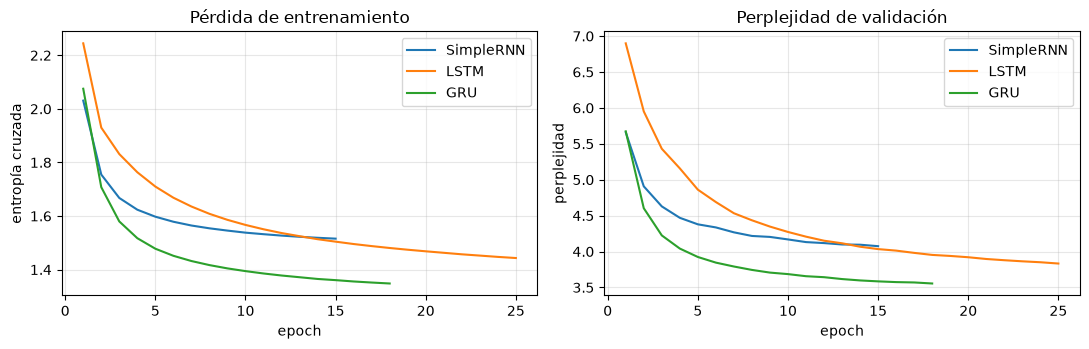

Mejor arquitectura por perplejidad de validación: GRU


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for name, r in results.items():
    axes[0].plot(range(1, len(r["loss"]) + 1), r["loss"], label=name)
    axes[1].plot(range(1, len(r["ppl"]) + 1), r["ppl"], label=name)
axes[0].set(title="Pérdida de entrenamiento", xlabel="epoch", ylabel="entropía cruzada")
axes[1].set(title="Perplejidad de validación", xlabel="epoch", ylabel="perplejidad")
for ax in axes:
    ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

best_name = min(results, key=lambda n: min(results[n]["ppl"]))
print("Mejor arquitectura por perplejidad de validación:", best_name)

### Conclusiones de la comparación de arquitecturas

| | Parámetros | Epochs (corte) | ppl val | ppl val (ctx≥50) | Tiempo |
|---|---|---|---|---|---|
| SimpleRNN | 58.245 | 15 | 4,07 | 3,97 | 30 min |
| LSTM | 205.845 | 25 | 3,83 | 3,72 | 139 min |
| GRU | 157.245 | **18** | **3,56** | **3,45** | 76 min |

Con el criterio de corte por plateau (mejora relativa < 0,5% durante 4 epochs), los tres modelos entrenaron hasta un punto comparable en vez de cortar por un tope de epochs arbitrario. Con eso:

- **GRU es la mejor arquitectura** en este corpus: menor perplejidad de validación, con menos parámetros que LSTM (157k vs 206k) y en un tercio del tiempo. Ya había señales de esto en la corrida anterior (10 epochs fijas), pero acá se confirma con LSTM entrenado hasta su propio plateau, no cortado antes de tiempo.
- **LSTM mejoró bastante más** que en la corrida anterior (ppl 4,27 → 3,83) al dejarlo entrenar 25 epochs en vez de 10, pero incluso así no alcanza a GRU. Con este tamaño de corpus y de contexto (100 caracteres), las compuertas extra de LSTM no se traducen en mejor generalización; solo agregan costo de entrenamiento.
- **SimpleRNN** es la que menos mejora margen tiene (cortó primero, en la epoch 15) y queda última en perplejidad, aunque no muy lejos de LSTM y con una fracción de sus parámetros y su tiempo de entrenamiento. Para un modelo de lenguaje simple por caracteres, con contextos cortos, el desvanecimiento del gradiente de la celda de Elman no pesa tanto como se esperaría en secuencias de texto normal.

**Conclusión práctica**: se usa el modelo GRU (`models/GRU.keras`) para la generación de secuencias del punto 4, por ser el de mejor perplejidad y el de mejor relación costo/beneficio frente a LSTM.

## 4. Generación de secuencias

Se usa el modelo GRU, el de mejor perplejidad de validación. Todas las estrategias comparten:

- **Encoding**: el texto semilla se tokeniza y se rellena con padding a la izquierda (`padding="pre"`) hasta `MAX_CONTEXT_SIZE`, igual que en entrenamiento.
- **Predicción por posición**: el modelo devuelve una distribución de probabilidad por cada posición de la secuencia (many-to-many); para generar el siguiente carácter solo se usa la **última posición** de la salida.

In [12]:
from tensorflow.keras.utils import pad_sequences

model = keras.models.load_model("models/GRU.keras")

def encode(text, max_length=MAX_CONTEXT_SIZE):
    ids = [char2idx[ch] for ch in text.lower() if ch in char2idx]
    return pad_sequences([ids], maxlen=max_length, padding="pre")

def decode(ids):
    return "".join(idx2char[i] for i in ids)

### Greedy search

En cada paso se agrega el carácter de mayor probabilidad (`argmax`). Es determinístico: la misma semilla siempre genera la misma continuación. Tiende a caer en bucles (repetir la misma palabra o frase) porque nunca se aparta del camino más probable, aunque ese camino a nivel de toda la secuencia no sea el mejor.

In [13]:
def generate_greedy(model, seed_text, n_chars, max_length=MAX_CONTEXT_SIZE):
    text = seed_text
    for _ in range(n_chars):
        encoded = encode(text, max_length)
        probs = model.predict(encoded, verbose=0)[0, -1, :]
        next_id = np.argmax(probs)
        text += idx2char[next_id]
    return text

seed = "en un lugar de la mancha"
print(generate_greedy(model, seed, n_chars=120))

en un lugar de la mancha, y de la mancha, que es el de la tierra, y el de la tierra de la cabeza a la cabeza de la mancha, y de la mancha, que e


### Beam search

En vez de quedarse con un solo candidato por paso, se mantienen `num_beams` secuencias en paralelo (el *beam*) y en cada paso se expanden todas sus continuaciones posibles, quedándose con las `num_beams` de mayor probabilidad acumulada (en log, para evitar underflow numérico).

- **Determinístico** (`mode='det'`): en cada paso se toman siempre los `num_beams` candidatos de mayor probabilidad. Sigue siendo reproducible, pero explora más que greedy porque no descarta una secuencia solo por no ser la mejor en un paso intermedio.
- **Estocástico** (`mode='sto'`): los candidatos se muestrean con `np.random.choice`, ponderados por `softmax(log_probs / temp)`. Introduce variedad: dos corridas con la misma semilla dan resultados distintos.

In [14]:
from scipy.special import softmax

def select_candidates(preds, num_beams, vocab_size, history_probs, history_tokens, temp, mode):
    """A partir de las predicciones de cada beam, arma todos los candidatos (beam x vocab_size)
    y selecciona los `num_beams` mejores según el modo."""
    pred_large = np.concatenate([
        np.log(pp + 1e-10) + history_probs[idx] for idx, pp in enumerate(preds)
    ])

    if mode == "det":
        idx_select = np.argsort(pred_large)[::-1][:num_beams]
    elif mode == "sto":
        idx_select = np.random.choice(
            len(pred_large), size=num_beams, replace=False, p=softmax(pred_large / temp)
        )
    else:
        raise ValueError(f"mode debe ser 'det' o 'sto', se recibió {mode!r}")

    beam_idx = idx_select // vocab_size
    char_idx = idx_select % vocab_size
    new_history_tokens = np.concatenate(
        [np.array(history_tokens)[beam_idx], char_idx[:, None]], axis=1
    )
    return pred_large[idx_select], new_history_tokens


def beam_search(model, seed_text, n_chars, num_beams=10, temp=1.0, mode="det",
                 max_length=MAX_CONTEXT_SIZE):
    """Devuelve las `num_beams` secuencias generadas (seed + n_chars), ordenadas
    de mayor a menor probabilidad acumulada."""
    encoded = encode(seed_text, max_length)
    probs = model.predict(encoded, verbose=0)[0, -1, :]
    vocab_size = probs.shape[0]

    history_probs = [0.0] * num_beams
    history_tokens = [encoded[0]] * num_beams
    history_probs, history_tokens = select_candidates(
        [probs], num_beams, vocab_size, history_probs, history_tokens, temp, mode)

    for step in range(n_chars - 1):
        preds = []
        for hist in history_tokens:
            window = hist[step + 1:][None, :]
            preds.append(model.predict(window, verbose=0)[0, -1, :])
        history_probs, history_tokens = select_candidates(
            preds, num_beams, vocab_size, history_probs, history_tokens, temp, mode)

    order = np.argsort(history_probs)[::-1]
    tail = history_tokens[order][:, -(len(seed_text) + n_chars):]
    return [decode(seq) for seq in tail], history_probs[order]

In [15]:
seqs, log_probs = beam_search(model, seed, n_chars=120, num_beams=10, mode="det")
print("BEAM SEARCH DETERMINÍSTICO (mejor secuencia):")
print(seqs[0])

BEAM SEARCH DETERMINÍSTICO (mejor secuencia):
en un lugar de la mancha, porque se le dijo: — señor —respondió don quijote—, porque se le dijo: — señor —respondió don quijote—, porque no hay 


### Efecto de la temperatura en el muestreo estocástico

La temperatura escala los logits antes del softmax: `softmax(log_probs / temp)`.

- **`temp` baja** (< 1): agudiza la distribución, el muestreo se acerca al determinístico y casi siempre elige el candidato más probable.
- **`temp` = 1**: usa las probabilidades del modelo tal cual.
- **`temp` alta** (> 1): aplana la distribución, da más chance a candidatos poco probables. El texto se vuelve más variado pero también menos coherente y con más errores.

In [16]:
np.random.seed(SEED)

for temp in (0.2, 0.7, 1.0, 1.5):
    seqs, _ = beam_search(model, seed, n_chars=120, num_beams=10, temp=temp, mode="sto")
    print(f"--- temperatura = {temp} ---")
    print(seqs[0])
    print()

--- temperatura = 0.2 ---
en un lugar de la mancha, porque se le dijo: — señor —respondió don quijote—, porque se le dijo: — señor —respondió don quijote—, porque no hay 



--- temperatura = 0.7 ---
en un lugar de la mancha, dijo: — señor —respondió don quijote—, porque el señor don quijote de la mancha que le dijo: — señor —respondió sancho



--- temperatura = 1.0 ---
en un lugar de la mancha, con todo esto, con esto se le respondió don quijote. — no me parece —respondió don quijote—, porque si estuvieron los 



--- temperatura = 1.5 ---
en un lugar de la mancha, sancho —dijo don quijote—, que no se le dijo: — así es —dijo don quijote—, porque ellos se había de ser de lo que en e



### Comparación

Mismo contexto inicial y misma longitud generada para las tres estrategias.

In [17]:
seed = "en un lugar de la mancha"
n_chars = 150

print("GREEDY")
print(generate_greedy(model, seed, n_chars))
print()

det_seqs, _ = beam_search(model, seed, n_chars, num_beams=10, mode="det")
print("BEAM SEARCH DETERMINÍSTICO")
print(det_seqs[0])
print()

np.random.seed(SEED)
sto_seqs, _ = beam_search(model, seed, n_chars, num_beams=10, temp=0.7, mode="sto")
print("BEAM SEARCH ESTOCÁSTICO (temp=0.7)")
print(sto_seqs[0])

GREEDY


en un lugar de la mancha, y de la mancha, que es el de la tierra, y el de la tierra de la cabeza a la cabeza de la mancha, y de la mancha, que es el de la tierra, y el de la 



BEAM SEARCH DETERMINÍSTICO
en un lugar de la mancha, porque se le dijo: — señor —respondió don quijote—, porque se le dijo: — señor —respondió don quijote—, porque se le dijo: — señor —respondió sancho



BEAM SEARCH ESTOCÁSTICO (temp=0.7)
en un lugar de la mancha, que es verdad que es verdad que se le había de llevar en el mundo, porque no se le dijo: — señor —replicó don quijote—, que no se había de decir que


### Conclusiones de la generación

- **Greedy** es la más rápida (una sola predicción por paso) pero la más propensa a repetirse en bucles, porque nunca reconsidera una elección subóptima de un paso anterior.
- **Beam search determinístico** mejora algo la coherencia local frente a greedy (frases con más sentido gramatical), pero en la corrida real también cae en un bucle: repite "—señor —respondió don quijote—" porque esa frase tiene probabilidad muy alta en el corpus. Explorar varias hipótesis en paralelo no elimina el problema de los bucles, solo lo hace menos frecuente; sigue siendo determinístico y cuesta `num_beams` veces más cómputo por paso que greedy.
- **Beam search estocástico** agrega diversidad real (dos corridas dan textos distintos) a costa de coherencia. La temperatura regula ese balance: temperaturas bajas (~0,2–0,5) dan texto parecido al determinístico pero con algo de variedad; temperaturas altas (≥1,5) producen combinaciones de caracteres poco probables y menos texto reconocible como español.
- Ninguna estrategia genera español gramaticalmente perfecto: es esperable con un modelo por caracteres de este tamaño (157k parámetros) entrenado sobre un solo libro. El modelo aprendió razonablemente bien ortografía, espaciado y palabras frecuentes, pero no estructura sintáctica de oraciones largas.